# Jupyter Basics with Real Country Data

Practice loading data from API, pandas DataFrames, and basic plotting in Jupyter.


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
print("All packages loaded!")

All packages loaded!


In [2]:
response = requests.get("https://restcountries.com/v3.1/all?fields=name,population,region,subregion")
countries = response.json()
print(f"Got data on {len(countries)} countries")

Got data on 250 countries


In [4]:
df = pd.DataFrame([
    {
        "Country": c["name"]["common"],
        "Population": c["population"],
        "Region": c["region"],
        "Subregion": c.get("subregion", "Unknown")
    }
    for c in countries
])
df.head(20)

,Country,Population,Region,Subregion
0,Cook Islands,15040,Oceania,Polynesia
1,Guinea,14363931,Africa,Western Africa
2,Christmas Island,1692,Oceania,Australia and New Zealand
3,Togo,8095498,Africa,Western Africa
4,Taiwan,23317031,Asia,Eastern Asia
5,Kyrgyzstan,7281800,Asia,Central Asia
6,Suriname,616500,Americas,South America
7,Dominican Republic,10771504,Americas,Caribbean
8,Guatemala,18079810,Americas,Central America
9,Algeria,47400000,Africa,Northern Africa


In [5]:
df.sort_values("Population", ascending=False).head(15)

,Country,Population,Region,Subregion
187,India,1417492000,Asia,Southern Asia
95,China,1408280000,Asia,Eastern Asia
184,United States,340110988,Americas,North America
231,Indonesia,284438782,Asia,South-Eastern Asia
68,Pakistan,241499431,Asia,Southern Asia
113,Nigeria,223800000,Africa,Western Africa
139,Brazil,213421037,Americas,South America
195,Bangladesh,169828911,Asia,Southern Asia
229,Russia,146028325,Europe,Eastern Europe
158,Mexico,130575786,Americas,North America


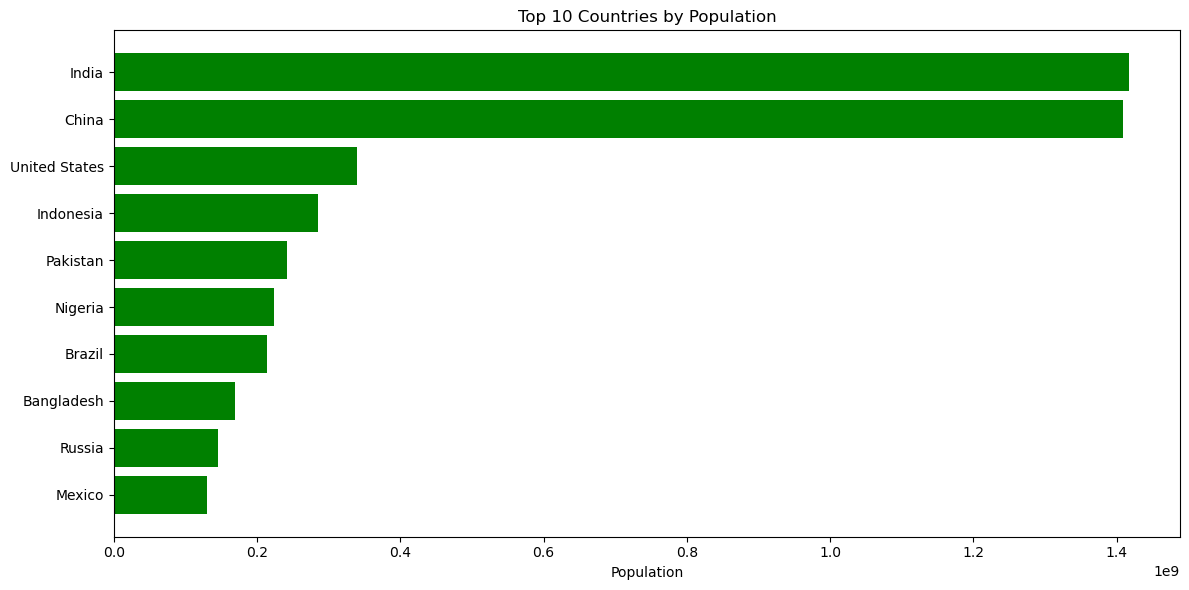

In [10]:
top15 = df.sort_values("Population", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top15["Country"][::-1], top15["Population"][::-1], color="green")
plt.title("Top 10 Countries by Population")
plt.xlabel("Population")
plt.tight_layout()
plt.show()

In [11]:
big_americas = df[(df["Region"] == "Americas") & (df["Population"] > 50_000_000)]
big_americas.sort_values("Population", ascending=False)

,Country,Population,Region,Subregion
184,United States,340110988,Americas,North America
139,Brazil,213421037,Americas,South America
158,Mexico,130575786,Americas,North America
166,Colombia,53057212,Americas,South America


In [12]:
subregion_stats = df.groupby("Subregion").agg(
    Countries=("Country", "count"),
    Total_Pop=("Population", "sum"),
    Avg_Pop=("Population", "mean")
).sort_values("Total_Pop", ascending=False)

subregion_stats.head(15)

,Countries,Total_Pop,Avg_Pop
Subregion,,,
Southern Asia,9,2011599527,2.235111e+08
Eastern Asia,8,1643675155,2.054594e+08
South-Eastern Asia,11,684495959,6.222691e+07
North America,7,512464843,7.320926e+07
Western Africa,17,440272026,2.589835e+07
Eastern Africa,19,439557603,2.313461e+07
South America,14,437051029,3.121793e+07
Western Asia,17,301836418,1.775508e+07
Northern Africa,7,263193663,3.759909e+07


In [13]:
subregion_stats["Avg_Pop"] = subregion_stats["Avg_Pop"].apply(lambda x: f"{x:,.0f}")
subregion_stats["Total_Pop"] = subregion_stats["Total_Pop"].apply(lambda x: f"{x:,.0f}")
subregion_stats.head(15)

,Countries,Total_Pop,Avg_Pop
Subregion,,,
Southern Asia,9,"2,011,599,527","223,511,059"
Eastern Asia,8,"1,643,675,155","205,459,394"
South-Eastern Asia,11,"684,495,959","62,226,905"
North America,7,"512,464,843","73,209,263"
Western Africa,17,"440,272,026","25,898,354"
Eastern Africa,19,"439,557,603","23,134,611"
South America,14,"437,051,029","31,217,931"
Western Asia,17,"301,836,418","17,755,083"
Northern Africa,7,"263,193,663","37,599,095"


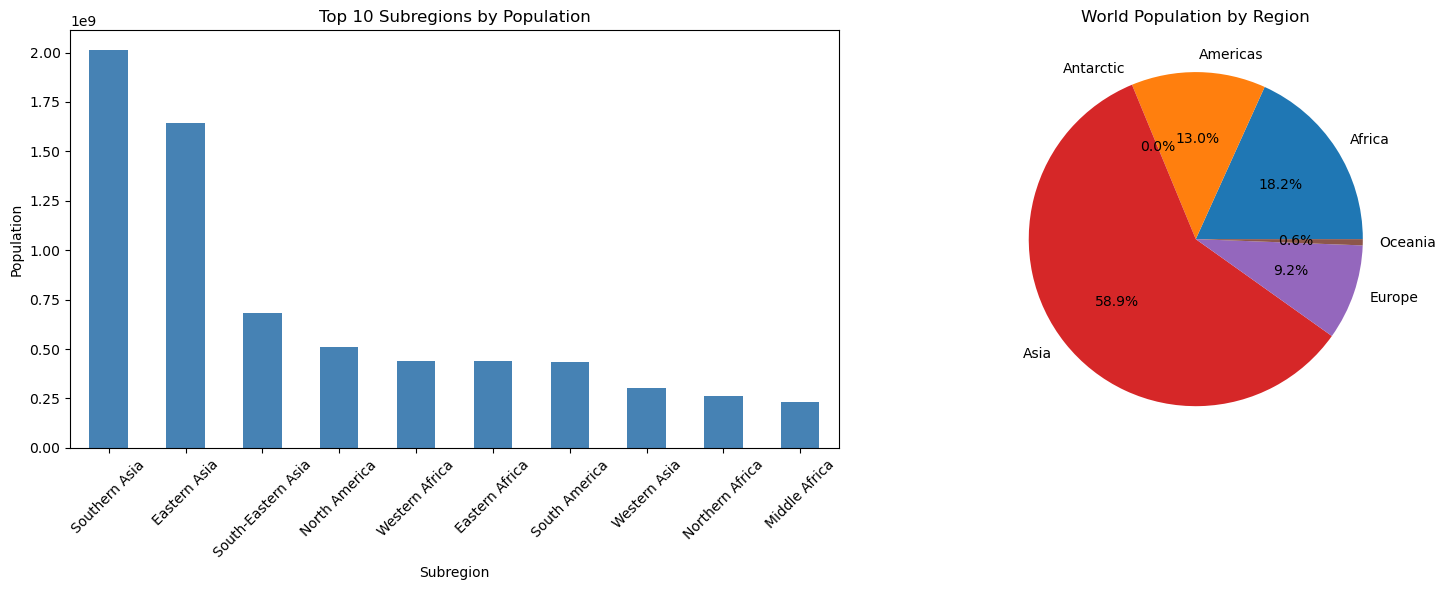

In [14]:
top10_sub = df.groupby("Subregion")["Population"].sum().sort_values(ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left chart: bar chart of top 10 subregions
top10_sub.plot(kind="bar", ax=ax1, color="steelblue")
ax1.set_title("Top 10 Subregions by Population")
ax1.set_ylabel("Population")
ax1.tick_params(axis='x', rotation=45)

# Right chart: pie chart of regions
region_pop = df.groupby("Region")["Population"].sum()
region_pop.plot(kind="pie", ax=ax2, autopct='%1.1f%%')
ax2.set_title("World Population by Region")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()